In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
nodes = pd.read_csv("../data/graphs/only_connected/nodes.csv")
edges = pd.read_csv("../data/graphs/only_connected/edges.csv")

# quick sanity checks
print(nodes.shape, edges.shape)
print(nodes.columns.tolist())
print(edges.columns.tolist())


(86762, 40) (1426829, 3)
['artist_mbid', 'artist_name', 'window_years', 'debut_date', 'window_cutoff_date', 'releases_total', 'releases_per_year', 'avg_days_between_releases', 'release_velocity_releases_per_day', 'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days', 'max_dry_spell_days', 'front_loading_index', 'tracks_total', 'collab_track_rate', 'unique_collaborator_count', 'label_diversity_count', 'label_churn', 'label_hhi', 'primary_label', 'all_labels_str', 'duration_ms_mean', 'duration_ms_median', 'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate', 'genre_count', 'genre_entropy', 'primary_genre', 'all_genres_str', 'artist_country', 'artist_region_city', 'years_active', 'debut_year', 'debut_decade', 'recency_index', 'primary_role', 'all_roles_str']
['u', 'v', 'weight']


In [ ]:
G = nx.Graph()

# add nodes (keep attributes if you want them later)
# Using artist_mbid as the node id
for _, row in nodes.iterrows():
    G.add_node(row["artist_mbid"], **row.to_dict())

# add edges (u, v, weight)
for _, row in edges.iterrows():
    u = row["u"]
    v = row["v"]
    w = row.get("weight", 1)
    if pd.notna(u) and pd.notna(v):
        G.add_edge(u, v, weight=float(w) if pd.notna(w) else 1.0)

print("Nodes in G:", G.number_of_nodes())
print("Edges in G:", G.number_of_edges())


In [ ]:
degrees = np.array([d for _, d in G.degree()])
deg_pos = degrees[degrees > 0]

# log-spaced bins
bins = np.logspace(
    np.log10(deg_pos.min()),
    np.log10(deg_pos.max()),
    num=15
)

In [ ]:
import json

with open('../data/figures/bins_data.json', 'w') as f:
    f.write(json.dumps({'bins':bins,'deg_pos':deg_pos}))

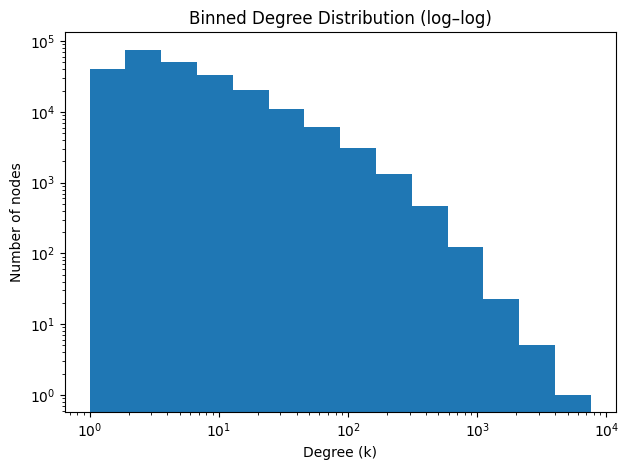

In [ ]:


plt.figure()
plt.hist(deg_pos, bins=bins)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree (k)")
plt.ylabel("Number of nodes")
plt.title("Binned Degree Distribution (log–log)")
plt.tight_layout()
plt.show()

In [ ]:
comp_sizes = np.array([len(c) for c in nx.connected_components(G)])
s, counts = np.unique(comp_sizes, return_counts=True)

In [ ]:
with open('../data/figures/components_data.json', 'w') as f:
    f.write(json.dumps({'comp_sizes':comp_sizes,'s':s, 'counts':counts}))

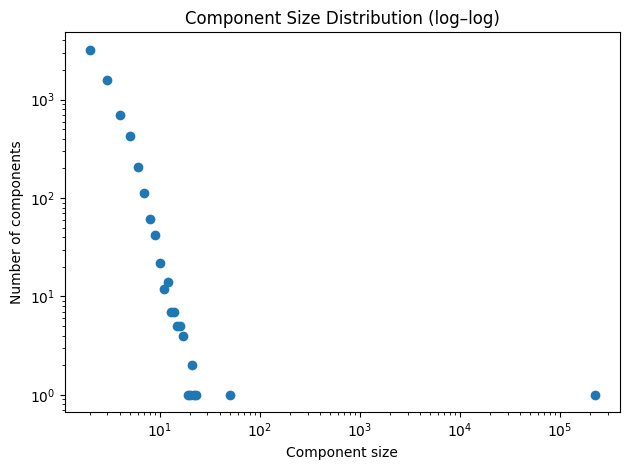

Number of components: 6464
Largest component size: 223031
Fraction in largest component: 0.9169438357459719


In [ ]:
# sizes of connected components


plt.figure()
plt.loglog(s, counts, marker="o", linestyle="none")
plt.xlabel("Component size")
plt.ylabel("Number of components")
plt.title("Component Size Distribution (log–log)")
plt.tight_layout()
plt.show()

# optional: print giant component share
giant = comp_sizes.max() if len(comp_sizes) else 0
print("Number of components:", len(comp_sizes))
print("Largest component size:", giant)
print("Fraction in largest component:", giant / G.number_of_nodes() if G.number_of_nodes() else np.nan)


In [ ]:
gcc_nodes = max(nx.connected_components(G), key=len)
G_gcc = G.subgraph(gcc_nodes).copy()

In [ ]:
# Approximate shortest-path length distribution by sampling sources
# (exact all-pairs is too expensive at this scale)
rng = np.random.default_rng(0)
n_sources = 10_000  # increase for smoother estimates; keep modest for speed
sources = rng.choice(list(G_gcc.nodes()), size=min(n_sources, G_gcc.number_of_nodes()), replace=False)

all_dists = []
for s in sources:
    dist = nx.single_source_shortest_path_length(G_gcc, s)
    all_dists.extend(dist.values())  # includes 0 to itself

# Remove zeros (self-distances) for the histogram
all_dists = np.array(all_dists, dtype=int)
all_dists = all_dists[all_dists > 0]


In [ ]:
with open('../data/figures/path_length_data.json', 'w') as f:
    f.write(json.dumps({'all_dists':all_dists}))

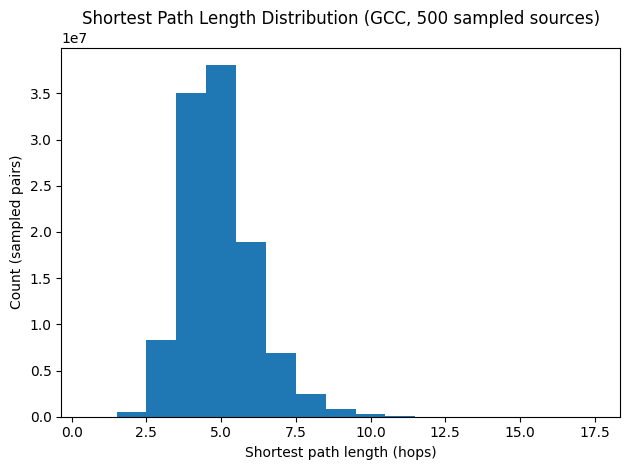

Sampled mean distance:   4.933
Sampled median distance: 5
Sampled max distance:    17 (lower bound on diameter)


In [ ]:

plt.figure()
bins = np.arange(all_dists.min(), all_dists.max() + 2) - 0.5  # integer-centered bins
plt.hist(all_dists, bins=bins)
plt.xlabel("Shortest path length (hops)")
plt.ylabel("Count (sampled pairs)")
plt.title(f"Shortest Path Length Distribution (GCC, {len(sources)} sampled sources)")
plt.tight_layout()
plt.show()

print(f"Sampled mean distance:   {all_dists.mean():.3f}")
print(f"Sampled median distance: {np.median(all_dists):.0f}")
print(f"Sampled max distance:    {all_dists.max():.0f} (lower bound on diameter)")


In [ ]:
deg = dict(G_gcc.degree())
clust = nx.clustering(G_gcc)  # local clustering coefficient for each node

k = np.array([deg[v] for v in G_gcc.nodes()], dtype=float)
c = np.array([clust[v] for v in G_gcc.nodes()], dtype=float)

# keep only positive degree nodes (should all be >0 in GCC, but safe)
mask = k > 0
k = k[mask]
c = c[mask]

# Log-binning of degree
n_bins = 20
bin_edges = np.logspace(np.log10(k.min()), np.log10(k.max()), n_bins + 1)

bin_centers = []
c_means = []
counts = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (k >= lo) & (k < hi)
    if not np.any(in_bin):
        continue
    # geometric mean for center is standard on log axes
    bin_centers.append(np.sqrt(lo * hi))
    c_means.append(c[in_bin].mean())
    counts.append(in_bin.sum())

bin_centers = np.array(bin_centers)
c_means = np.array(c_means)
counts = np.array(counts)


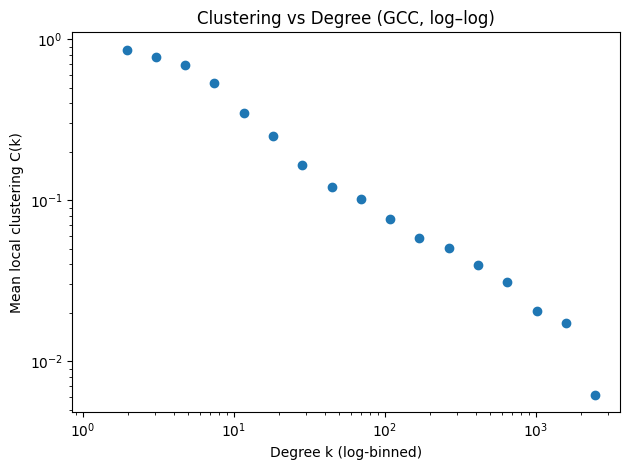

In [ ]:

plt.figure()
plt.plot(bin_centers, c_means, marker="o", linestyle="none")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log-binned)")
plt.ylabel("Mean local clustering C(k)")
plt.title("Clustering vs Degree (GCC, log–log)")
plt.tight_layout()
plt.show()